In [2]:
#getting all necessary importables
import stim, sinter, pymatching
from typing import List
from matplotlib import pyplot as plt

### Featuring the Rotated X Surface Code

In [3]:
tasks = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d,
            distance=d,
            before_round_data_depolarization=noise,
        ),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [11,13,15,17,19]
    for noise in [0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
)

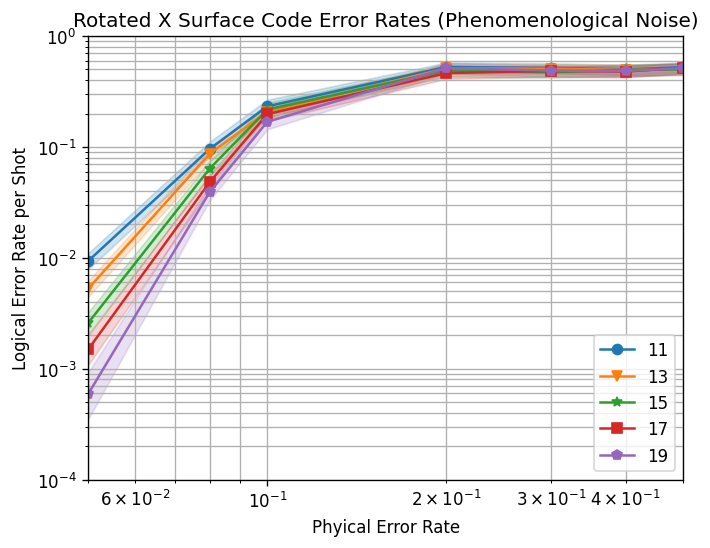

In [4]:
fig, ax = plt.subplots(1,1)

sinter.plot_error_rate(
    stats=collected_stats,
    ax=ax,
    x_func= lambda stats: stats.json_metadata['p'],
    group_func= lambda stats: stats.json_metadata['d'],
)

ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Rotated X Surface Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)